# Semantic SLAM: Telemetry & Performance Evaluation

Questo notebook analizza l'accuratezza del sistema confrontando i dati grezzi dei sensori (Odometria e Percezione Visiva) e i dati processati dal filtro probabilistico contro la Ground Truth (GT) assoluta della simulazione.

## Metriche Considerate:
1. **Absolute Trajectory Error (ATE):** Scostamento euclideo tra la posizione reale dell'agente e quella calcolata dall'odometria.
2. **Object Localization RMSE:** Errore quadratico medio nella stima dei centri degli oggetti percepiti (Pre vs Post Filtro).
3. **Detection Continuity (Flickering):** Frequenza con cui un oggetto sparisce e riappare a causa del rumore sulla confidence.

In [23]:
from os import read

import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configurazione RUN da analizzare
last_run_file = open("../log/last_run.txt", "r")
LAST_RUN_ID = last_run_file.read().strip()
last_run_file.close()

RUN_ID = LAST_RUN_ID # Modificare con l'ID effettivo
LOG_FILE = Path(f"../log/{RUN_ID}/telemetry.jsonl")

data = []
with open(LOG_FILE, 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.json_normalize(data)
df['timestamp'] = df['timestamp'] - df['timestamp'].iloc[0] # Normalizza il tempo a 0
print(f"Caricati {len(df)} sample di telemetria.")

Caricati 319 sample di telemetria.


## 1. Analisi Traiettoria (ATE - Absolute Trajectory Error)
Confronto tra i movimenti reali registrati nel motore fisico e la traiettoria accumulata con rumore dall'OdometrySystem.

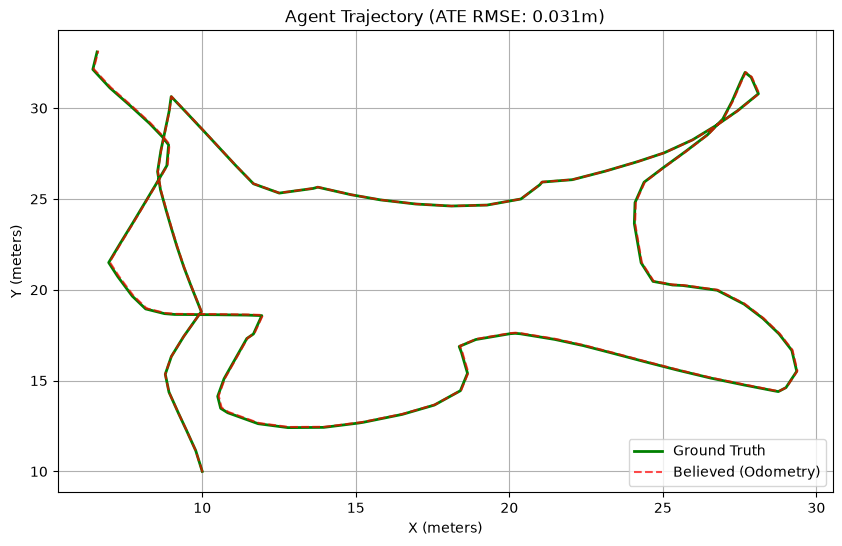

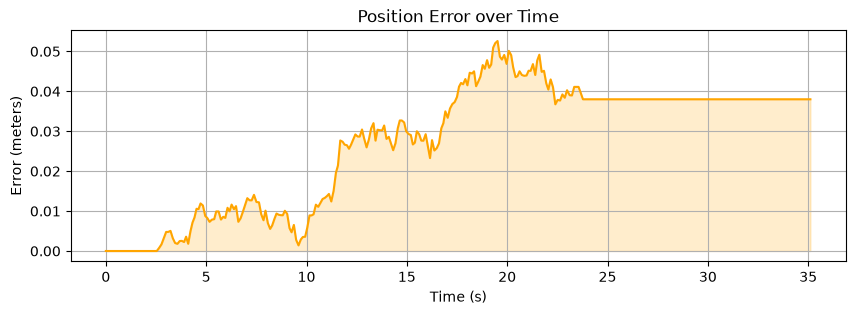

In [24]:
gt_x = [row['ground_truth.position'][0] for _, row in df.iterrows()]
gt_y = [row['ground_truth.position'][1] for _, row in df.iterrows()]

believed_x = [row['believed_pre_filter.position'][0] for _, row in df.iterrows()]
believed_y = [row['believed_pre_filter.position'][1] for _, row in df.iterrows()]

# Calcolo ATE
errors = np.sqrt((np.array(gt_x) - np.array(believed_x))**2 + (np.array(gt_y) - np.array(believed_y))**2)
ate_rmse = np.sqrt(np.mean(errors**2))

plt.figure(figsize=(10, 6))
plt.plot(gt_x, gt_y, label='Ground Truth', color='green', linewidth=2)
plt.plot(believed_x, believed_y, label='Believed (Odometry)', color='red', linestyle='dashed', alpha=0.7)
plt.title(f"Agent Trajectory (ATE RMSE: {ate_rmse:.3f}m)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(df['timestamp'], errors, color='orange')
plt.title("Position Error over Time")
plt.xlabel("Time (s)")
plt.ylabel("Error (meters)")
plt.fill_between(df['timestamp'], errors, color='orange', alpha=0.2)
plt.grid(True)
plt.show()

## 2. Accuratezza Localizzazione Oggetti (RMSE Visivo)
Per ogni oggetto rilevato, calcoliamo la discrepanza tra il centro perfetto, il centro distorto (raw_perception) e il centro corretto dal filtro (filtered_perception). Poiché al momento il filtro è un pass-through, le linee raw e filtered saranno sovrapposte.

Global RAW Perception RMSE: 0.4521 m
Global EMA Perception RMSE: 0.3353 m
Global WLS Perception RMSE: 0.0899 m
Global KF Perception RMSE: 0.1162 m
Global EKF Perception RMSE: 0.1576 m


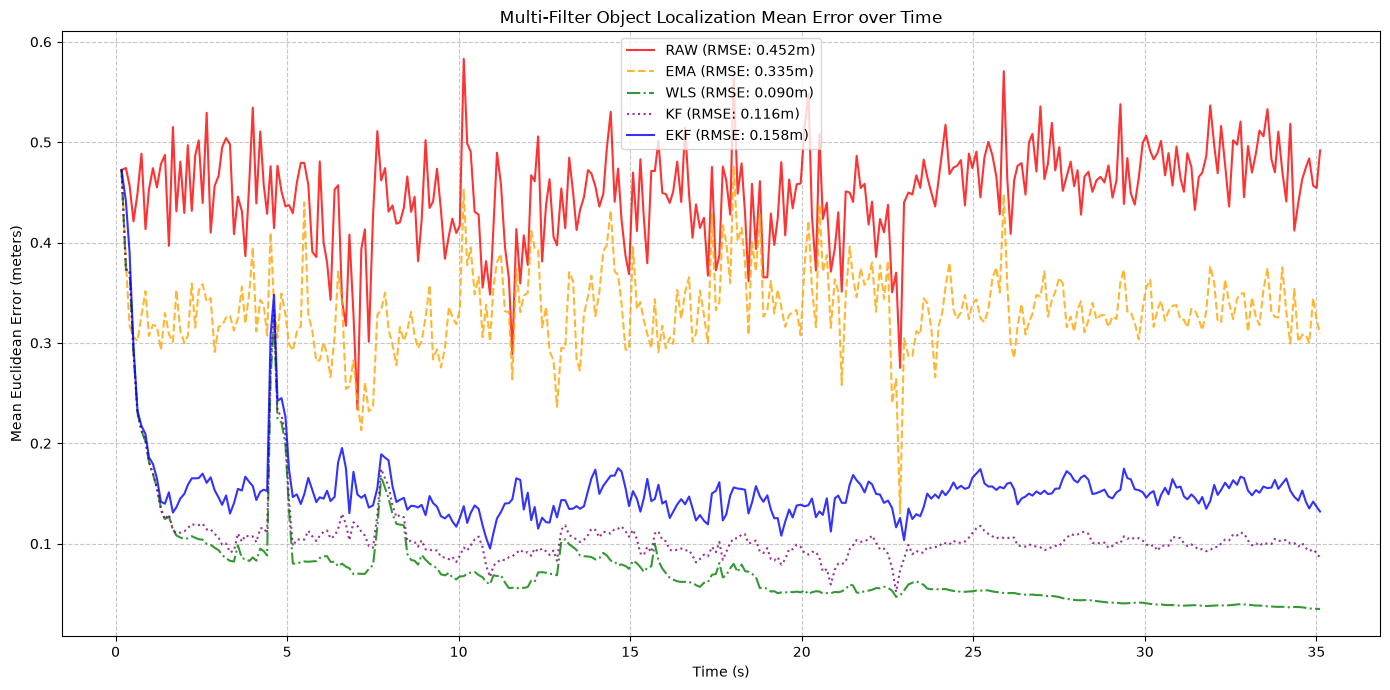

In [25]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Carica la mappa di Ground Truth della run specifica
MAP_FILE = Path(f"../log/{RUN_ID}/map.yaml")
with open(MAP_FILE, 'r') as f:
    map_data = yaml.safe_load(f)

# Estrai i centri reali (Ground Truth) degli oggetti
gt_objects = {
    obj_id: np.array(data['center']) 
    for obj_id, data in map_data.get('objects', {}).items()
}

# 2. Definiamo le chiavi dei filtri presenti nel log
filter_keys = ['raw', 'ema', 'wls', 'kf', 'ekf']

# Fix per l'appiattimento di json_normalize:
# Re-iniettiamo i dizionari originali prendendoli dai dati grezzi JSON
for key in filter_keys:
    df[f'{key}_perception_dict'] = [d.get(f'{key}_perception', {}) for d in data]

def calculate_perception_error(row, perception_key):
    errors = []
    perceived = row.get(perception_key)
    
    if not isinstance(perceived, dict) or not perceived: 
        return np.nan
    
    for obj_id, obj_data in perceived.items():
        if obj_id in gt_objects:
            perceived_center = np.array(obj_data['center'])
            gt_center = gt_objects[obj_id]
            
            # Distanza euclidea tra percezione distorta e realtà
            error = np.linalg.norm(perceived_center - gt_center)
            errors.append(error)
            
    return np.mean(errors) if errors else np.nan

# 3. Calcola le serie storiche usando le nuove colonne intatte
for key in filter_keys:
    df[f'{key}_obj_error'] = df.apply(lambda r: calculate_perception_error(r, f'{key}_perception_dict'), axis=1)

# 4. Calcola l'RMSE globale ignorando i frame vuoti (NaN)
rmses = {}
for key in filter_keys:
    rmses[key] = np.sqrt(np.nanmean(df[f'{key}_obj_error']**2))
    print(f"Global {key.upper()} Perception RMSE: {rmses[key]:.4f} m")

# 5. Plot Comparativo
plt.figure(figsize=(14, 7))

# Setup di colori e stili per differenziare le linee
colors = {'raw': 'red', 'ema': 'orange', 'wls': 'green', 'kf': 'purple', 'ekf': 'blue'}
linestyles = {'raw': '-', 'ema': '--', 'wls': '-.', 'kf': ':', 'ekf': '-'}

for key in filter_keys:
    plt.plot(df['timestamp'], df[f'{key}_obj_error'], 
             label=f'{key.upper()} (RMSE: {rmses[key]:.3f}m)', 
             color=colors[key], linestyle=linestyles[key], alpha=0.8)

plt.title("Multi-Filter Object Localization Mean Error over Time")
plt.xlabel("Time (s)")
plt.ylabel("Mean Euclidean Error (meters)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Stabilità del Tracking (Flickering / False Negatives)
Analizza quante volte gli oggetti "lampeggiano" sparendo dal grafo a causa di una confidence inferiore alla soglia impostata nel `NoisyPerceptionSystem`.

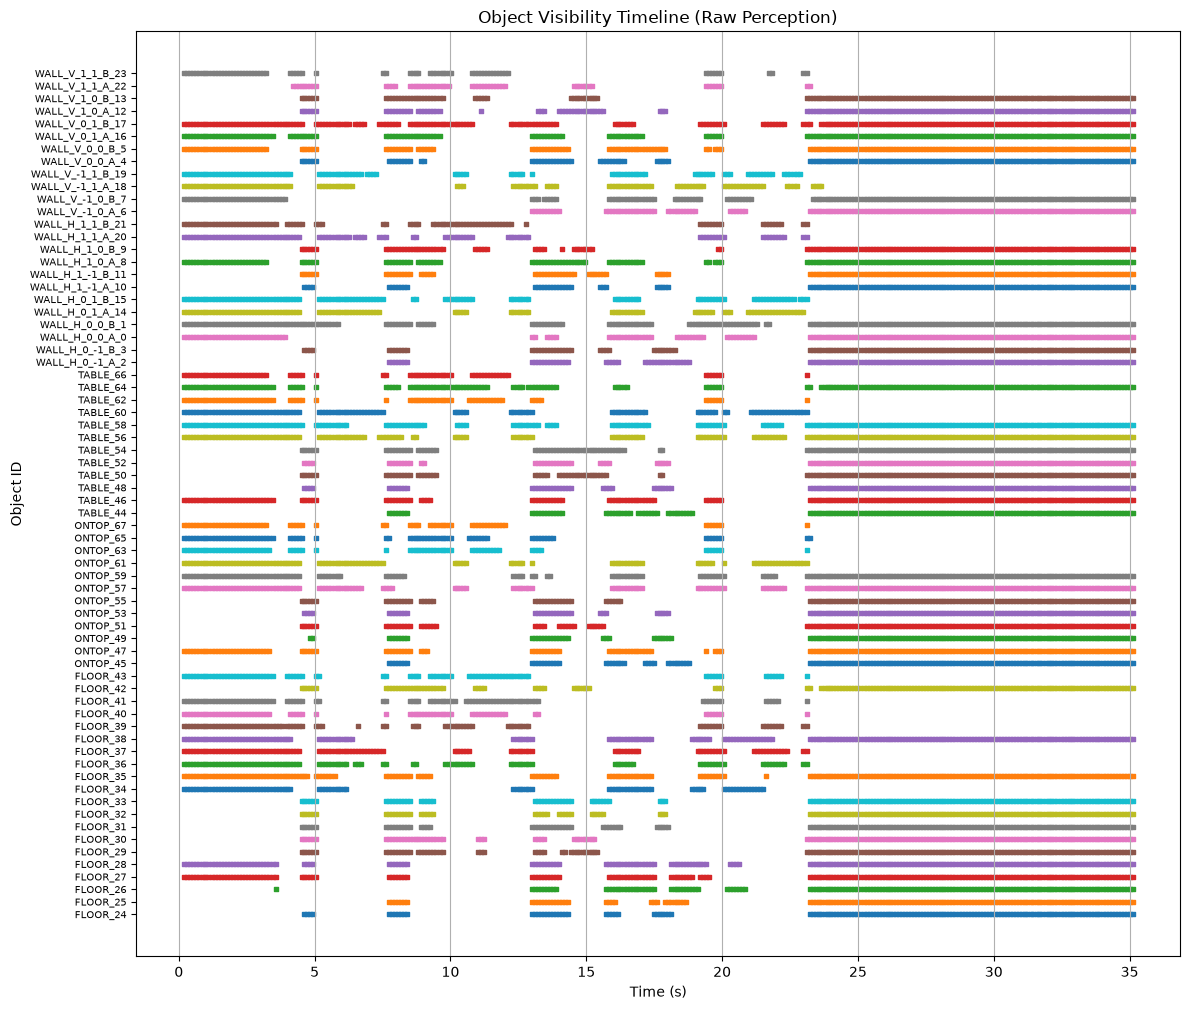

In [26]:
object_visibility = {}

for idx, row in df.iterrows():
    raw_p = row['raw_perception_dict'] 
    
    if isinstance(raw_p, dict):
        for obj_id in raw_p.keys():
            if obj_id not in object_visibility:
                object_visibility[obj_id] = np.zeros(len(df))
            object_visibility[obj_id][idx] = 1

# Ordina alfabeticamente per raggruppare visivamente oggetti simili (WALL, TABLE, ecc.)
sorted_objects = sorted(object_visibility.keys())

# Calcola un'altezza dinamica per la figura (minimo 4, più 0.15 pollici per ogni oggetto)
fig_height = max(4, len(sorted_objects) * 0.15)
plt.figure(figsize=(12, fig_height))

for i, obj_id in enumerate(sorted_objects):
    timeline = object_visibility[obj_id]
    plt.scatter(df['timestamp'][timeline == 1], np.full(int(sum(timeline)), i), s=5, marker='s')

# Applica le etichette ordinate e riduci drasticamente la dimensione del font
plt.yticks(range(len(sorted_objects)), sorted_objects, fontsize=7)

plt.title("Object Visibility Timeline (Raw Perception)")
plt.xlabel("Time (s)")
plt.ylabel("Object ID")
plt.grid(axis='x')

# Ottimizza i margini per sfruttare tutto lo spazio disponibile
plt.tight_layout()
plt.show()